In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
#This line ensures your graphs show up directly in the notebook %matplotlib inline


In [2]:
df = pd.read_csv('Documents/Financial_Market_Uncertainty_Dataset.csv')

In [3]:
#To see the rows
df.head(5)

,Sample_ID,Date,Open_Price,High_Price,Low_Price,Close_Price,Adjusted_Close,Trading_Volume,SMA,EMA,...,Gold_Price,VIX_Index,Drawdown,Volatility_Index,News_Sentiment_Score,Social_Media_Sentiment,Current_Portfolio_Value,Cash_Available,Holdings,Decision
0,FID_00001,2024-01-01,249.82,263.25,235.79,260.96,262.83,933346,101.35,456.23,...,1507.06,39.76,0.21,13.98,0.93,-0.35,326715.49,65496.12,728,Sell
1,FID_00002,2024-01-02,480.29,482.81,470.41,482.19,481.32,1141532,251.50,271.41,...,2009.44,10.94,29.91,23.19,0.38,-0.94,372672.00,69040.93,234,Hold
2,FID_00003,2024-01-03,392.80,398.40,390.74,390.77,388.57,1342309,104.91,318.24,...,2175.54,32.77,27.50,37.49,0.52,-0.14,77374.54,89262.71,834,Sell
3,FID_00004,2024-01-04,339.46,355.16,321.01,331.84,333.00,599202,245.87,196.83,...,2085.44,11.99,7.92,34.37,-0.80,-0.41,413453.80,85724.42,126,Buy
4,FID_00005,2024-01-05,162.41,173.46,142.78,168.47,170.87,2192509,296.66,151.34,...,2469.18,22.86,22.00,39.84,-0.50,0.63,67440.69,97220.99,676,Hold


In [4]:
#total entries and total columns
df.shape

(12000, 30)

In [5]:
#data cleaning process starts from here
df.info(12000)

<class 'pandas.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Sample_ID                12000 non-null  str    
 1   Date                     12000 non-null  str    
 2   Open_Price               12000 non-null  float64
 3   High_Price               12000 non-null  float64
 4   Low_Price                12000 non-null  float64
 5   Close_Price              12000 non-null  float64
 6   Adjusted_Close           12000 non-null  float64
 7   Trading_Volume           12000 non-null  int64  
 8   SMA                      12000 non-null  float64
 9   EMA                      12000 non-null  float64
 10  RSI                      12000 non-null  float64
 11  MACD                     12000 non-null  float64
 12  Bollinger_Bands          12000 non-null  float64
 13  ATR                      12000 non-null  float64
 14  Momentum                 12000 no

In [6]:
#to drop any entry,axis=1 means vertical column,inplace =true( to save it right there and then)
df.drop({'Decision','Holdings'},axis=1, inplace=True)

In [7]:
#to see whether the columns are droped or not
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 28 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Sample_ID                12000 non-null  str    
 1   Date                     12000 non-null  str    
 2   Open_Price               12000 non-null  float64
 3   High_Price               12000 non-null  float64
 4   Low_Price                12000 non-null  float64
 5   Close_Price              12000 non-null  float64
 6   Adjusted_Close           12000 non-null  float64
 7   Trading_Volume           12000 non-null  int64  
 8   SMA                      12000 non-null  float64
 9   EMA                      12000 non-null  float64
 10  RSI                      12000 non-null  float64
 11  MACD                     12000 non-null  float64
 12  Bollinger_Bands          12000 non-null  float64
 13  ATR                      12000 non-null  float64
 14  Momentum                 12000 no

In [8]:
#to see any null values
pd.isnull(df)

,Sample_ID,Date,Open_Price,High_Price,Low_Price,Close_Price,Adjusted_Close,Trading_Volume,SMA,EMA,...,Exchange_Rate,Crude_Oil_Price,Gold_Price,VIX_Index,Drawdown,Volatility_Index,News_Sentiment_Score,Social_Media_Sentiment,Current_Portfolio_Value,Cash_Available
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11995,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
11996,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
11997,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
11998,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [9]:
#total null values in columns
pd.isnull(df).sum()

Sample_ID                  0
Date                       0
Open_Price                 0
High_Price                 0
Low_Price                  0
Close_Price                0
Adjusted_Close             0
Trading_Volume             0
SMA                        0
EMA                        0
RSI                        0
MACD                       0
Bollinger_Bands            0
ATR                        0
Momentum                   0
Interest_Rate              0
Inflation_Rate             0
GDP_Growth                 0
Exchange_Rate              0
Crude_Oil_Price            0
Gold_Price                 0
VIX_Index                  0
Drawdown                   0
Volatility_Index           0
News_Sentiment_Score       0
Social_Media_Sentiment     0
Current_Portfolio_Value    0
Cash_Available             0
dtype: int64

In [10]:
#change data type
df['Drawdown'] = df['Drawdown'].astype('int')

In [11]:
#to see whether the data type is changed or not
df['Drawdown'].dtypes

dtype('int64')

In [12]:
df.columns

Index(['Sample_ID', 'Date', 'Open_Price', 'High_Price', 'Low_Price',
       'Close_Price', 'Adjusted_Close', 'Trading_Volume', 'SMA', 'EMA', 'RSI',
       'MACD', 'Bollinger_Bands', 'ATR', 'Momentum', 'Interest_Rate',
       'Inflation_Rate', 'GDP_Growth', 'Exchange_Rate', 'Crude_Oil_Price',
       'Gold_Price', 'VIX_Index', 'Drawdown', 'Volatility_Index',
       'News_Sentiment_Score', 'Social_Media_Sentiment',
       'Current_Portfolio_Value', 'Cash_Available'],
      dtype='str')

In [13]:
#rename column
df.rename(columns={'Cash_Available':'Moolah_Touse'})

,Sample_ID,Date,Open_Price,High_Price,Low_Price,Close_Price,Adjusted_Close,Trading_Volume,SMA,EMA,...,Exchange_Rate,Crude_Oil_Price,Gold_Price,VIX_Index,Drawdown,Volatility_Index,News_Sentiment_Score,Social_Media_Sentiment,Current_Portfolio_Value,Moolah_Touse
0,FID_00001,2024-01-01,249.82,263.25,235.79,260.96,262.83,933346,101.35,456.23,...,64.59,53.56,1507.06,39.76,0,13.98,0.93,-0.35,326715.49,65496.12
1,FID_00002,2024-01-02,480.29,482.81,470.41,482.19,481.32,1141532,251.50,271.41,...,89.09,125.55,2009.44,10.94,29,23.19,0.38,-0.94,372672.00,69040.93
2,FID_00003,2024-01-03,392.80,398.40,390.74,390.77,388.57,1342309,104.91,318.24,...,62.14,130.25,2175.54,32.77,27,37.49,0.52,-0.14,77374.54,89262.71
3,FID_00004,2024-01-04,339.46,355.16,321.01,331.84,333.00,599202,245.87,196.83,...,75.66,87.44,2085.44,11.99,7,34.37,-0.80,-0.41,413453.80,85724.42
4,FID_00005,2024-01-05,162.41,173.46,142.78,168.47,170.87,2192509,296.66,151.34,...,79.78,89.28,2469.18,22.86,22,39.84,-0.50,0.63,67440.69,97220.99
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11995,FID_11996,2056-11-03,101.86,120.21,96.29,110.07,114.73,1014668,226.55,462.57,...,72.40,149.69,1716.04,11.58,1,35.01,0.95,-0.45,440136.09,52177.37
11996,FID_11997,2056-11-04,449.47,458.61,447.82,448.64,447.37,3317297,435.83,345.93,...,69.29,118.64,2023.50,11.26,10,6.23,-0.29,-0.61,287167.95,86347.85
11997,FID_11998,2056-11-05,222.93,231.11,208.12,220.03,218.08,4462876,112.20,189.99,...,84.61,79.40,2335.73,38.99,13,29.41,0.08,-0.72,93799.75,56090.20
11998,FID_11999,2056-11-06,475.44,480.84,470.00,470.95,470.02,4699786,203.26,156.15,...,70.30,114.74,1756.95,45.54,17,31.37,0.37,0.06,96727.00,20508.30


In [14]:
#describe() method returns descrition of the data in the dataframe 
df.describe()

,Open_Price,High_Price,Low_Price,Close_Price,Adjusted_Close,Trading_Volume,SMA,EMA,RSI,MACD,...,Exchange_Rate,Crude_Oil_Price,Gold_Price,VIX_Index,Drawdown,Volatility_Index,News_Sentiment_Score,Social_Media_Sentiment,Current_Portfolio_Value,Cash_Available
count,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,1.200000e+04,12000.000000,12000.000000,12000.000000,12000.000000,...,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000
mean,298.417960,309.045912,288.002435,298.520930,298.527489,2.561351e+06,300.649373,299.040734,49.876668,0.014068,...,74.963801,99.653008,2004.761625,30.088076,14.486917,22.508327,0.009913,0.000653,253984.110174,50553.099015
std,115.304141,115.438677,115.384773,115.464406,115.526734,1.393928e+06,114.662855,116.140742,23.063901,2.900784,...,8.697834,28.947694,288.598219,11.597411,8.668915,10.047123,0.577645,0.576858,141512.589948,28632.056544
min,100.000000,101.240000,82.430000,85.940000,84.690000,1.002330e+05,100.050000,100.040000,10.000000,-5.000000,...,60.000000,50.000000,1500.030000,10.000000,0.000000,5.000000,-1.000000,-1.000000,10017.670000,1000.840000
25%,198.770000,209.535000,188.477500,199.195000,199.105000,1.362576e+06,200.997500,196.817500,29.670000,-2.510000,...,67.210000,74.435000,1756.120000,20.000000,7.000000,13.930000,-0.490000,-0.500000,130551.710000,25757.787500
50%,297.565000,308.140000,286.590000,297.210000,297.890000,2.568708e+06,301.930000,300.070000,50.130000,0.015000,...,75.010000,99.605000,2003.585000,30.005000,15.000000,22.430000,0.020000,0.010000,254223.325000,50423.685000
75%,397.795000,408.697500,387.165000,397.575000,397.492500,3.761663e+06,400.340000,400.157500,69.652500,2.570000,...,82.480000,124.922500,2253.430000,39.990000,22.000000,31.142500,0.520000,0.500000,375109.115000,75495.312500
max,499.890000,518.640000,497.610000,516.850000,516.100000,4.999678e+06,499.950000,500.000000,90.000000,5.000000,...,90.000000,150.000000,2499.980000,50.000000,30.000000,39.990000,1.000000,1.000000,499919.800000,99992.790000


In [28]:
df[['Open_Price','GDP_Growth','ATR']].describe()

,Open_Price,GDP_Growth,ATR
count,12000.000000,12000.000000,12000.000000
mean,298.417960,2.562588,8.076513
std,115.304141,4.323690,4.045855
min,100.000000,-5.000000,1.000000
25%,198.770000,-1.140000,4.560000
50%,297.565000,2.560000,8.100000
75%,397.795000,6.330000,11.600000
max,499.890000,10.000000,15.000000


In [15]:
df.columns

Index(['Sample_ID', 'Date', 'Open_Price', 'High_Price', 'Low_Price',
       'Close_Price', 'Adjusted_Close', 'Trading_Volume', 'SMA', 'EMA', 'RSI',
       'MACD', 'Bollinger_Bands', 'ATR', 'Momentum', 'Interest_Rate',
       'Inflation_Rate', 'GDP_Growth', 'Exchange_Rate', 'Crude_Oil_Price',
       'Gold_Price', 'VIX_Index', 'Drawdown', 'Volatility_Index',
       'News_Sentiment_Score', 'Social_Media_Sentiment',
       'Current_Portfolio_Value', 'Cash_Available'],
      dtype='str')

<Axes: xlabel='GDP_Growth', ylabel='count'>

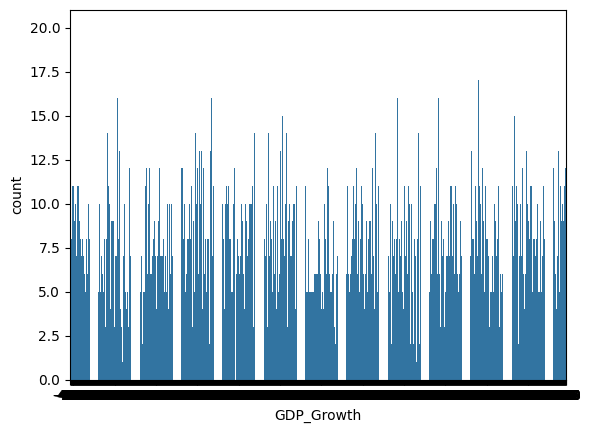

In [16]:
#For exploratory data analysis
sns.countplot(x='GDP_Growth',data=df)

In [17]:
#to save the file of juypter in it
df.to_csv('Cleaned_Financial_Data.csv',index=False)

In [18]:
#to see where the file is stored
import os
os.listdir()

['.idlerc',
 '.ipynb_checkpoints',
 '.ipython',
 '.jupyter',
 '.matplotlib',
 '.python_history',
 '3D Objects',
 'AppData',
 'Application Data',
 'Cleaned_Financial_Data.csv',
 'Contacts',
 'Cookies',
 'Desktop',
 'Documents',
 'Downloads',
 'Favorites',
 'IntelGraphicsProfiles',
 'Links',
 'Local Settings',
 'Music',
 'My Documents',
 'NetHood',
 'NTUSER.DAT',
 'ntuser.dat.LOG1',
 'ntuser.dat.LOG2',
 'NTUSER.DAT{ba91eaf4-8634-11f0-929d-5c5f674685a7}.TM.blf',
 'NTUSER.DAT{ba91eaf4-8634-11f0-929d-5c5f674685a7}.TMContainer00000000000000000001.regtrans-ms',
 'NTUSER.DAT{ba91eaf4-8634-11f0-929d-5c5f674685a7}.TMContainer00000000000000000002.regtrans-ms',
 'ntuser.ini',
 'OneDrive',
 'Pictures',
 'PrintHood',
 'Recent',
 'Saved Games',
 'Searches',
 'SendTo',
 'Start Menu',
 'Templates',
 'Untitled.ipynb',
 'Untitled1.ipynb',
 'Untitled2.ipynb',
 'Videos']

In [19]:
# 1. First, ensure Date is in the right format
df['Date'] = pd.to_datetime(df['Date'])

# 2. Extract the Year to a new column
df['Year'] = df['Date'].dt.year

# 3. Group by Year and calculate the average GDP Growth
annual_gdp = df.groupby('Year')['GDP_Growth'].mean()

print(annual_gdp)

Year
2024    2.986557
2025    2.625781
2026    2.204959
2027    2.555342
2028    2.537678
2029    2.670110
2030    2.832164
2031    2.488575
2032    2.607814
2033    2.267123
2034    2.584000
2035    2.849616
2036    2.543798
2037    2.707918
2038    2.209096
2039    2.596192
2040    2.447814
2041    2.607205
2042    2.184521
2043    2.431890
2044    2.542459
2045    2.375370
2046    2.412849
2047    2.615808
2048    2.869426
2049    2.586466
2050    2.341151
2051    2.776356
2052    2.596038
2053    3.002959
2054    2.425397
2055    2.816247
2056    2.214455
Name: GDP_Growth, dtype: float64


In [20]:
df.columns

Index(['Sample_ID', 'Date', 'Open_Price', 'High_Price', 'Low_Price',
       'Close_Price', 'Adjusted_Close', 'Trading_Volume', 'SMA', 'EMA', 'RSI',
       'MACD', 'Bollinger_Bands', 'ATR', 'Momentum', 'Interest_Rate',
       'Inflation_Rate', 'GDP_Growth', 'Exchange_Rate', 'Crude_Oil_Price',
       'Gold_Price', 'VIX_Index', 'Drawdown', 'Volatility_Index',
       'News_Sentiment_Score', 'Social_Media_Sentiment',
       'Current_Portfolio_Value', 'Cash_Available', 'Year'],
      dtype='str')

In [24]:
#to see the table or group of 2 columns such as year and GDP_Growth,different names and different columns can be grouped together
df.groupby('Year')['GDP_Growth'].std()

Year
2024    4.292681
2025    4.313075
2026    4.334911
2027    4.296621
2028    4.213353
2029    4.179085
2030    4.142358
2031    4.403434
2032    4.355850
2033    4.378957
2034    4.261345
2035    4.496439
2036    4.486240
2037    4.245695
2038    4.297558
2039    4.402535
2040    4.221186
2041    4.384984
2042    4.505570
2043    4.193557
2044    4.419921
2045    4.483412
2046    4.292358
2047    4.352166
2048    4.255466
2049    4.251988
2050    4.382624
2051    4.316111
2052    4.232843
2053    4.412761
2054    4.099513
2055    4.422522
2056    4.328808
Name: GDP_Growth, dtype: float64

In [26]:
#to find the maximum gdp growth in different years
df.groupby('Year')['GDP_Growth'].max()

Year
2024     9.99
2025     9.93
2026    10.00
2027     9.99
2028     9.99
2029     9.89
2030     9.98
2031     9.99
2032     9.96
2033     9.99
2034     9.98
2035    10.00
2036     9.99
2037     9.93
2038     9.97
2039    10.00
2040     9.98
2041     9.98
2042     9.99
2043     9.95
2044     9.97
2045     9.98
2046     9.97
2047     9.97
2048     9.87
2049     9.83
2050     9.99
2051     9.95
2052     9.99
2053     9.98
2054     9.98
2055     9.96
2056     9.95
Name: GDP_Growth, dtype: float64

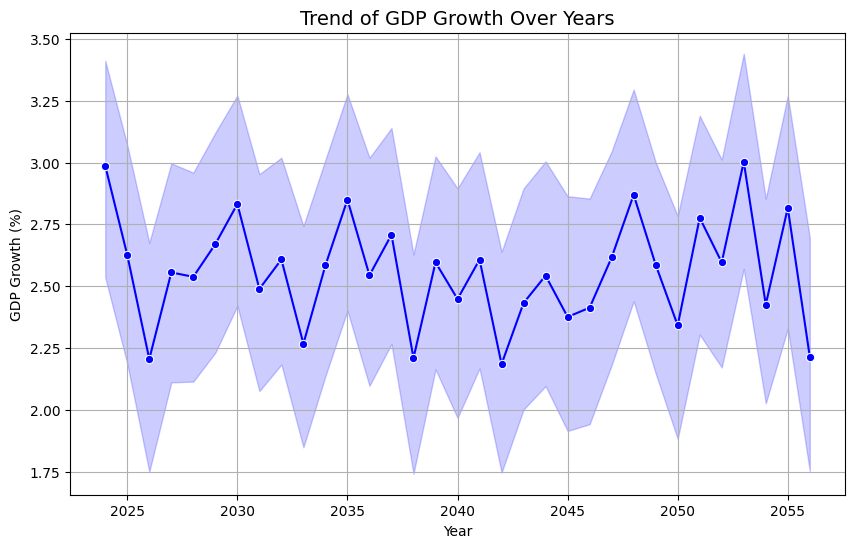

In [29]:
#line plot to show how GDP variable changes over time
import matplotlib.pyplot as plt
import seaborn as sns

# Create a Line Plot
plt.figure(figsize=(10, 6))
sns.lineplot(data=df, x='Year', y='GDP_Growth', marker='o', color='blue')

# Add titles and labels
plt.title('Trend of GDP Growth Over Years', fontsize=14)
plt.xlabel('Year')
plt.ylabel('GDP Growth (%)')
plt.grid(True) # Adds a grid to make it easier to read values
plt.show()

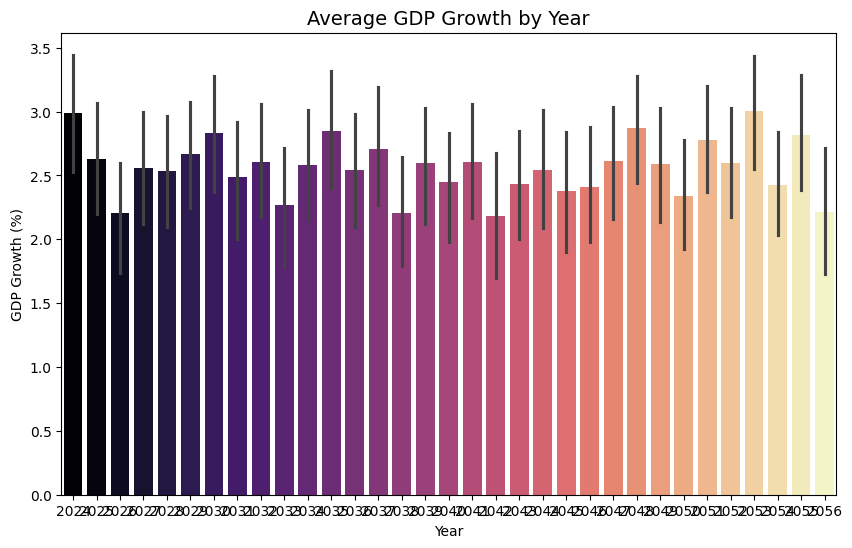

In [31]:
#specific height of growth for each year clearly,use a bar plot
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='Year', y='GDP_Growth', hue='Year', palette='magma', legend=False)

plt.title('Average GDP Growth by Year', fontsize=14)
plt.xlabel('Year')
plt.ylabel('GDP Growth (%)')
plt.show()

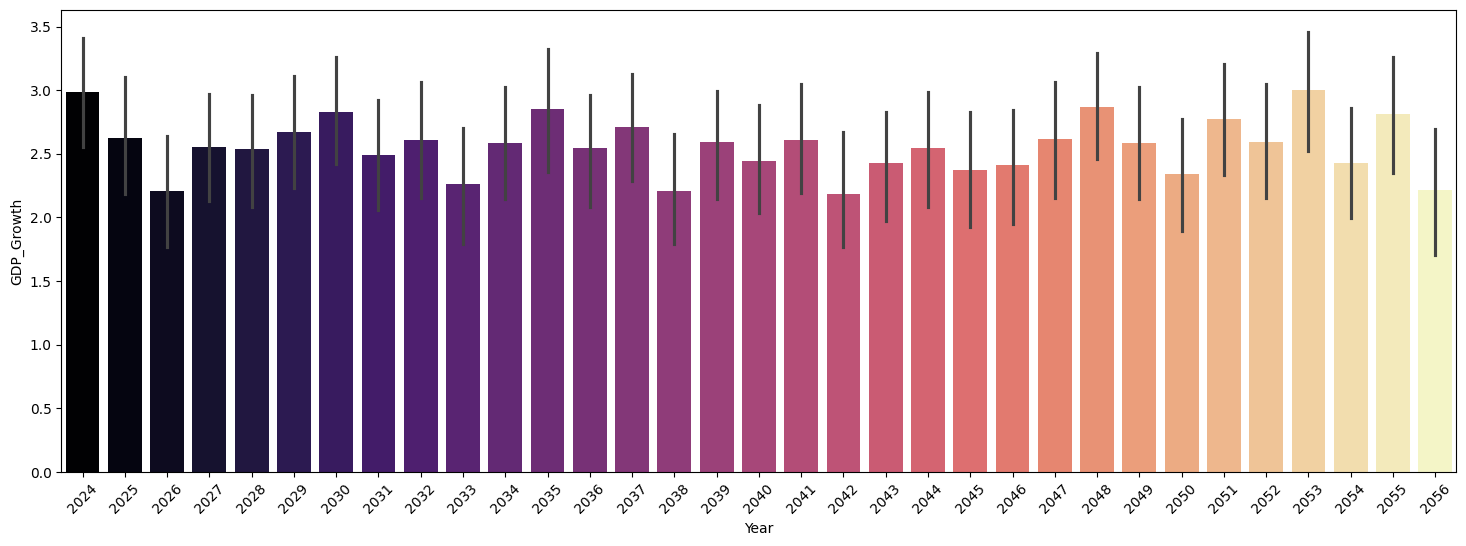

In [33]:
#to change the width and length of the graph(to avoid from overlapping)
import matplotlib.pyplot as plt
import seaborn as sns

# Set a wide figure size so years don't overlap
plt.figure(figsize=(18, 6)) 

# Plot your data
sns.barplot(data=df, x='Year', y='GDP_Growth', hue='Year', palette='magma', legend=False)

# Optional: Rotate the year labels so they fit better
plt.xticks(rotation=45) 

plt.show()

In [ ]:
#the following graph shows different levels of GDP_Growth in different years  